
### H1N1 and Seasonal Flu Vaccine Uptake
#### Additional Explanations

In [ ]:
# Import packages
import pandas as pd, numpy as np, pickle, dalex, shap

# Import our models and predictions from the pickle file
with open('modelling_output.pickle', 'rb') as file:
    modelling_output = pickle.load(file)

%matplotlib inline

##### [Shapley Values](https://shap.readthedocs.io/en/latest/index.html)

In [ ]:
colnames = modelling_output["xgb_tuned_model"]["preprocess"].get_feature_names_out(modelling_output["xgb_tuned_model"]["preprocess"].feature_names_in_)
X_train_t = pd.DataFrame(modelling_output["xgb_tuned_model"]["preprocess"].fit_transform(modelling_output["X_train"]).toarray(), columns = colnames)
X_test_t  = pd.DataFrame(modelling_output["xgb_tuned_model"]["preprocess"].fit_transform(modelling_output["X_test"]).toarray(), columns = colnames)

In [ ]:
# https://github.com/shap/shap/issues/2399
explainer = shap.Explainer(modelling_output["xgb_tuned_model"]["xgb_tuned"], X_train_t)

In [ ]:
shap_values = explainer(X_test_t)

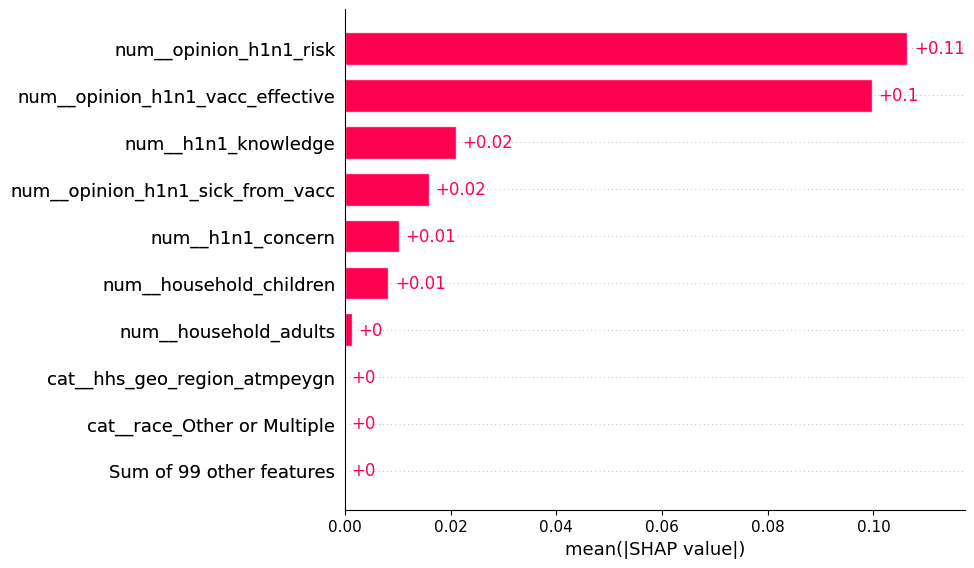

In [ ]:
shap.plots.bar(shap_values)

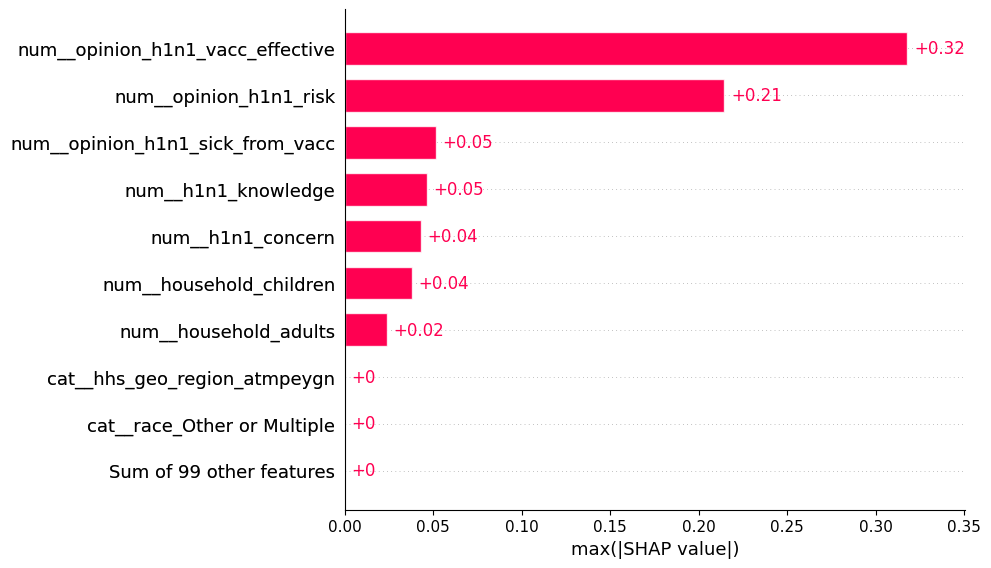

In [ ]:
shap.plots.bar(shap_values.abs.max(0))

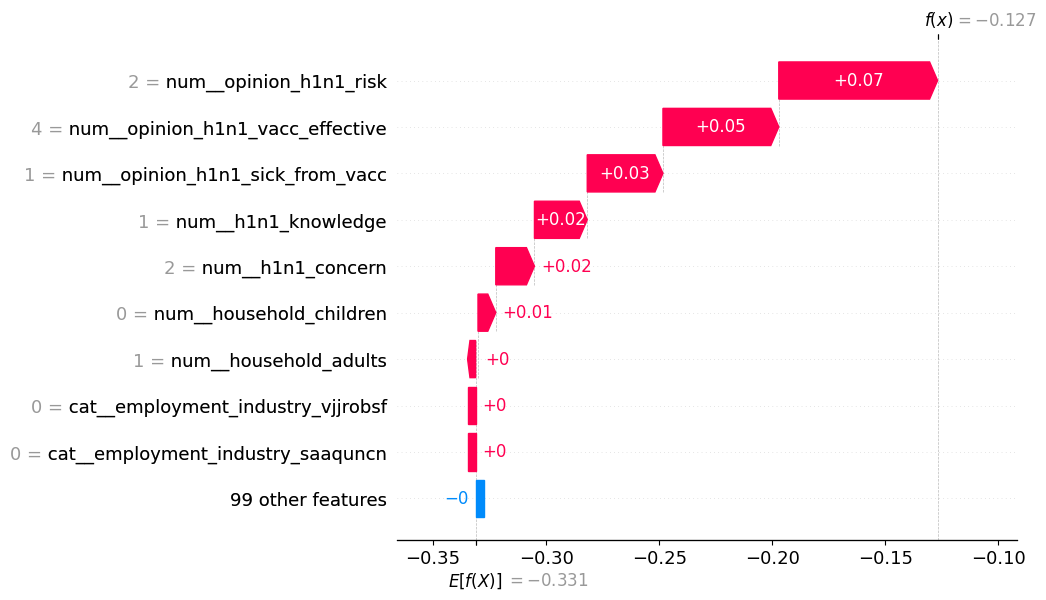

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.initjs() # https://github.com/shap/shap/issues/279
shap.plots.force(shap_values[0])

In [ ]:
shap.force_plot(shap_values[:500,])

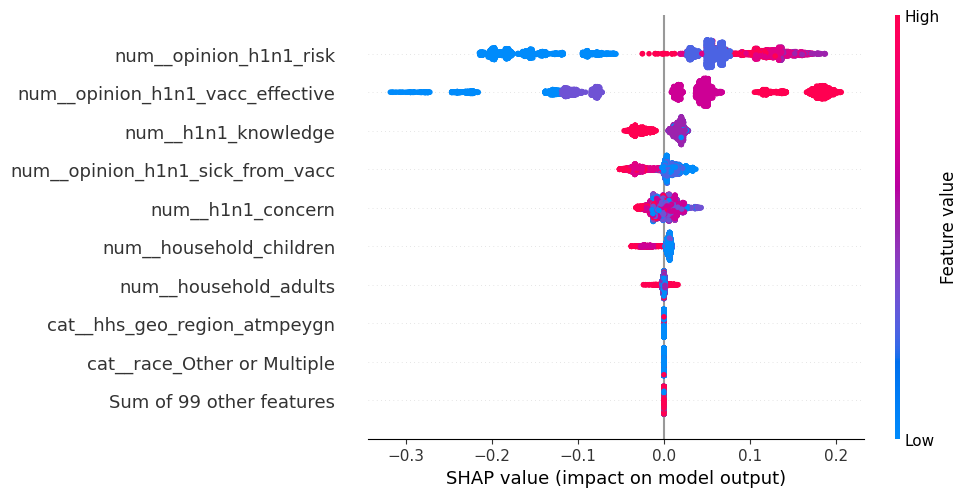

In [ ]:
shap.plots.beeswarm(shap_values)

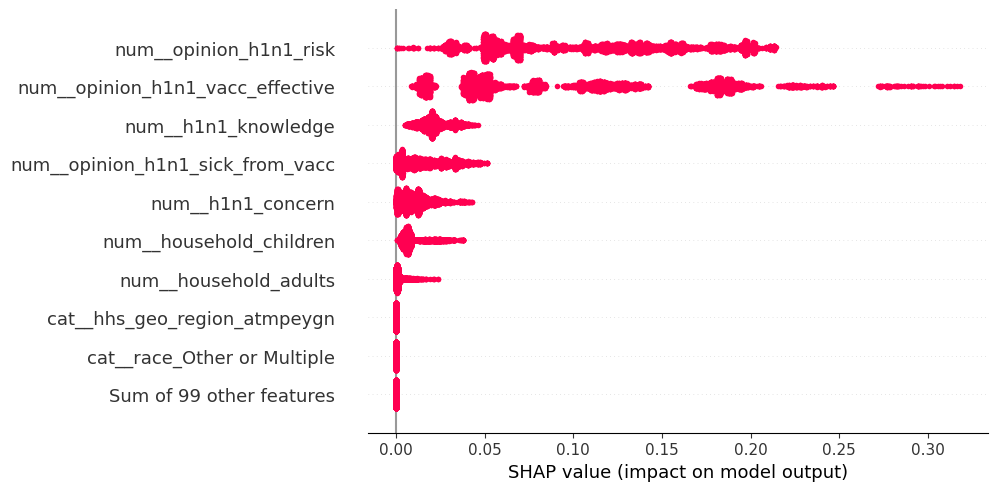

In [ ]:
shap.plots.beeswarm(shap_values.abs, color = "shap_red")

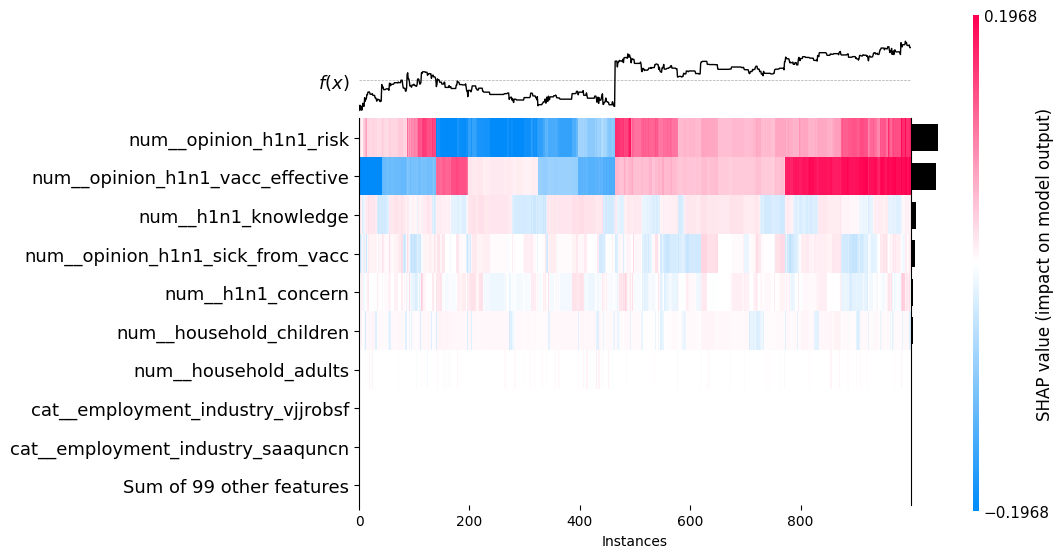

<Axes: xlabel='Instances'>

In [ ]:
shap.plots.heatmap(shap_values[:1000])

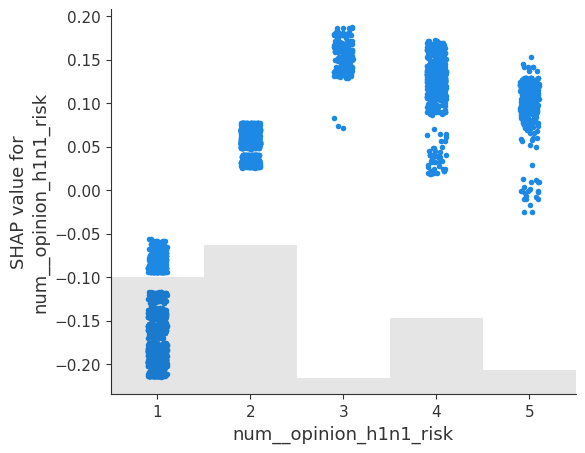

In [ ]:
shap.plots.scatter(shap_values[:, "num__opinion_h1n1_risk"])

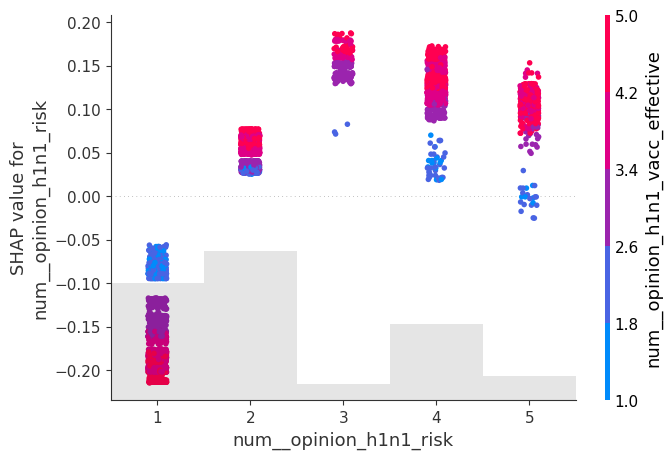

In [ ]:
shap.plots.scatter(shap_values[:, "num__opinion_h1n1_risk"], color = shap_values)

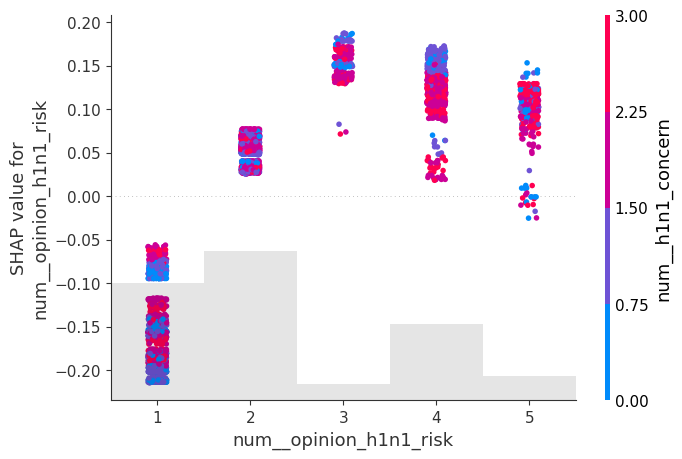

In [ ]:
shap.plots.scatter(shap_values[:, "num__opinion_h1n1_risk"], color = shap_values[:, "num__h1n1_concern"])